# **Lab 02 - Introduction to Q-learning**

##### Copyright by UIT-NC@NT549

## **Some instructions before getting started**:
<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify;">

Start the Kernel: At the top right, choose <strong>Select Kernel ➞ Python Environments...</strong>

You can run all code blocks to check: From the menu bar, choose <strong>Run All</strong>.

Complete all code blocks marked with the comment <span style="font-family: monospace; font-weight: bold; color:white; background-color: green;"> ### YOU NEED TO WRITE YOUR CODE BELOW ### </span>
</div>

## Part 1: Implementing Q-learning with the FrozenLake-v1 environment

In [1]:
# import Gymnasium library and alias as gym
import gymnasium as gym
import random

In [5]:
# ============================================================
# Q-learning agent for Gymnasium FrozenLake-v1
# ------------------------------------------------------------
# This script trains an agent to learn a state-action value table
# Q(s, a) using the Q-learning algorithm and an epsilon-greedy policy.
#
# Environment:
# - FrozenLake-v1 (4x4 by default)
# - is_slippery=False -> deterministic movement (easier learning)
#
# High-level flow:
# 1) Create environment and agent
# 2) Train over many episodes
# 3) Print and export learned Q-table
# 4) Demonstrate the learned policy in text mode and pygame mode
# ============================================================


class QLearningAgent:
    # Agent stores Q-values in a dictionary keyed by (state, action).
    # If a (state, action) pair has never been seen, its Q-value is treated as 0.
    def __init__(self, env, alpha=0.1, gamma=0.9):
        self.env = env
        self.alpha = alpha  # Learning rate: how much to update old Q-values
        self.gamma = gamma  # Discount factor: importance of future rewards
        self.q_table = {}   # Sparse Q-table: {(state, action): q_value}

    def get_q_value(self, state, action):
        # Return Q(s, a). If missing, return 0.0 (default for unseen pairs).
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        return self.q_table.get((state, action), 0.0)

    def update_q_value(self, state, action, reward, next_state):
        # Q-learning update rule:
        #   Q(s,a) <- (1 - alpha)*Q(s,a) + alpha*(reward + gamma*max_a' Q(s',a'))
        #
        # 1) Estimate best possible future value at next_state
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        best_next_q = max(
            self.get_q_value(next_state, a) for a in range(self.env.action_space.n)
        )

        # 2) Current estimate for (state, action)
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        current_q = self.get_q_value(state, action)

        # 3) Temporal-difference target
        # Reward for current step + discounted best future value
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        target_q = reward + self.gamma * best_next_q

        # 4) Blend old estimate with new target
        # New Q-value is a weighted average of old and new information
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        new_q = (1 - self.alpha) * current_q + self.alpha * target_q

        # 5) Save updated Q-value
        self.q_table[(state, action)] = new_q

    def choose_action(self, state, epsilon=0.1):
        # Epsilon-greedy action selection:
        # - With probability epsilon: explore (random action)
        # - Otherwise: exploit (choose action with highest Q-value)

        # 1) Exploration: random action with probability epsilon
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        if random.random() < epsilon:
            return self.env.action_space.sample()

        # Compute Q-values for all actions in current state
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        q_values = []
        for action in range (self.env.action_space.n):
            q_values.append(self.get_q_value(state, action))
        max_q = max(q_values)

        # Tie-breaking: if multiple actions share max Q, choose randomly among them
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        best_actions = [action for action, q in enumerate(q_values) if q == max_q]
        return random.choice(best_actions)

    def choose_greedy_action(self, state):
        # Pure greedy policy (epsilon=0):
        # Always choose one of the best actions by Q-value.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        q_values = [self.get_q_value(state, a) for a in range(self.env.action_space.n)] 
        max_q = max(q_values) 
        best_actions = [a for a, q in enumerate(q_values) if q == max_q] 
        return random.choice(best_actions)


def export_q_table_to_txt(agent, file_path="q_table_final.txt"):
    """Export all learned Q-values to a CSV-like text file.

    File format:
        State,Action,Q-value
        0,0,0.000000
        ...
    """
    with open(file_path, "w", encoding="utf-8") as f:
        f.write("State,Action,Q-value\n")
        # Sort keys for stable, readable output
        for (state, action) in sorted(agent.q_table.keys()):
            q_val = agent.q_table[(state, action)]
            f.write(f"{state},{action},{q_val:.6f}\n")
    print(f"Q-table exported to: {file_path}")


def show_final_result_text(agent):
    """Run one full evaluation episode in ANSI text mode.

    - Uses a greedy policy (no exploration).
    - Prints board state after each step.
    - Useful for notebook/terminal environments.
    """
    demo_env = gym.make("FrozenLake-v1", is_slippery=False, render_mode="ansi")
    state, _ = demo_env.reset()

    print("=== FINAL RUN WITH GREEDY POLICY (TEXT) ===")
    print(demo_env.render())

    done = False
    step = 0
    reward = 0

    while not done:
        # Pick best action according to learned Q-table
        action = agent.choose_greedy_action(state)

        # Interact with environment
        next_state, reward, terminated, truncated, _ = demo_env.step(action)

        # Episode stops if goal/hole reached (terminated) or cutoff (truncated)
        done = terminated or truncated
        step += 1

        # Log progress and render current map
        print(f"Step {step} - Action: {action}, Reward: {reward}")
        print(demo_env.render())

        # Move to next state
        state = next_state

    # Final status
    print("Agent reached the goal!" if reward > 0 else "Agent failed to reach the goal.")
    demo_env.close()


def show_final_result_pygame(agent, delay_seconds=0.5):
    """
    Run one full evaluation episode with GUI rendering ("human" mode).

    Note:
    - Requires a local environment that supports opening windows.
    - In remote/notebook servers without display, this may not work.
    """
    import time

    demo_env = gym.make("FrozenLake-v1", is_slippery=False, render_mode="human")
    state, _ = demo_env.reset()

    print("=== FINAL RUN WITH GREEDY POLICY (PYGAME/HUMAN) ===")
    done = False
    step = 0
    reward = 0

    while not done:
        action = agent.choose_greedy_action(state)
        next_state, reward, terminated, truncated, _ = demo_env.step(action)
        done = terminated or truncated
        step += 1

        print(f"Step {step} - Action: {action}, Reward: {reward}")
        state = next_state

        # Slow down transitions so movement can be observed clearly
        time.sleep(delay_seconds)

    print("Agent reached the goal!" if reward > 0 else "Agent failed to reach the goal.")

    # Keep final frame visible briefly
    time.sleep(1.0)
    demo_env.close()


# ============================================================
# Training routine
# ============================================================

if __name__ == "__main__":
    # Create deterministic FrozenLake environment for training
    ### YOU NEED TO WRITE YOUR CODE BELOW ###
    # HERE
    env = gym.make("FrozenLake-v1", is_slippery=False)  # Deterministic environment for easier learning

    # Initialize Q-learning agent with default hyperparameters
    ### YOU NEED TO WRITE YOUR CODE BELOW ###
    # HERE
    agent = QLearningAgent(env) 

    # Number of independent training episodes
    num_episodes = 1000

    # Main training loop
    for _ in range(num_episodes):
        # Reset environment at start of each episode
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        state, _ = env.reset()
        done = False

        # Roll out one episode until terminal state
        while not done:
            # Choose action with exploration
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            action = agent.choose_action(state, epsilon=0.1)  # 10% exploration rate

            # Execute action in environment
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # Update Q-table from transition (s, a, r, s')
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            agent.update_q_value(state, action, reward, next_state)

            # Advance to next state
            state = next_state

    # Print learned Q-table entries
    print("Training completed. Q-table:")
    for (state, action) in sorted(agent.q_table.keys()):
        q_val = agent.q_table[(state, action)]
        print(f"State: {state}, Action: {action}, Q-value: {q_val:.2f}")

    # Save Q-table to file for later inspection/use
    export_q_table_to_txt(agent, "q_table_final.txt")

    # Show one text-based demonstration run
    show_final_result_text(agent)

    # Show one GUI-based demonstration run
    show_final_result_pygame(agent, delay_seconds=0.4)

    # Release training environment resources
    env.close()

Training completed. Q-table:
State: 0, Action: 0, Q-value: 0.48
State: 0, Action: 1, Q-value: 0.39
State: 0, Action: 2, Q-value: 0.59
State: 0, Action: 3, Q-value: 0.49
State: 1, Action: 0, Q-value: 0.48
State: 1, Action: 1, Q-value: 0.00
State: 1, Action: 2, Q-value: 0.66
State: 1, Action: 3, Q-value: 0.53
State: 2, Action: 0, Q-value: 0.52
State: 2, Action: 1, Q-value: 0.73
State: 2, Action: 2, Q-value: 0.38
State: 2, Action: 3, Q-value: 0.62
State: 3, Action: 0, Q-value: 0.58
State: 3, Action: 1, Q-value: 0.00
State: 3, Action: 2, Q-value: 0.01
State: 3, Action: 3, Q-value: 0.03
State: 4, Action: 0, Q-value: 0.00
State: 4, Action: 1, Q-value: 0.00
State: 4, Action: 2, Q-value: 0.00
State: 4, Action: 3, Q-value: 0.51
State: 6, Action: 0, Q-value: 0.00
State: 6, Action: 1, Q-value: 0.81
State: 6, Action: 2, Q-value: 0.00
State: 6, Action: 3, Q-value: 0.61
State: 8, Action: 0, Q-value: 0.00
State: 8, Action: 1, Q-value: 0.00
State: 8, Action: 2, Q-value: 0.06
State: 8, Action: 3, Q-val

## Part 2: Q-learning with Custom Environment "VacuumCleaner"

In [ ]:
# Build a simple custom Gymnasium environment named "VacuumCleaner-v0".
# The environment simulates a vacuum robot operating in an m x n room. The robot can
# move up, down, left, and right and automatically vacuums the cell it occupies.
# The objective is to clean all dust particles in the room. There is a single obstacle
# located at a specified cell (i, j) that the robot must avoid. Entering the obstacle
# cell yields a large negative reward and terminates the episode.
# The robot receives a positive reward when it vacuums a dirty cell. If the robot
# attempts to vacuum an already clean cell, that action receives a reduced reward
# (e.g., penalized or halved). When all dust has been cleaned, the agent receives
# a large positive bonus reward and the episode terminates.
# Action space: Discrete(4) -> {0: up, 1: down, 2: left, 3: right}
# Observation space: Dict with 'position' (x, y) and 'dust' grid (m x n binary)

import numpy as np
import os
import time
from IPython.display import clear_output

class VacuumCleanerEnv(gym.Env):
    def __init__(self, m=5, n=5, obstacle=(2, 2)):
        super(VacuumCleanerEnv, self).__init__()
        self.m = m
        self.n = n
        self.obstacle = tuple(obstacle)

        # Action space: 0=up, 1=down, 2=left, 3=right
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE

        # Observation space: position and dust grid
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        self.observation_space = gym.spaces.Dict({
            'position': 
            'dust': 
        })

        self.reset()

    def reset(self, *, seed=None, options=None):
        # initialize position and dust
        # Start the robot at the top-left corner (row 0, column 0)
        # Use NUMPY to define.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        self.position = 

        # Initialize dust grid: 1 indicates dirty, 0 indicates clean.
        # Shape is (m, n) corresponding to the room dimensions.
        # Use NUMPY to define.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        self.dust_grid = 

        # Ensure the obstacle cell contains no dust (robot cannot clean there).
        # This also prevents rewarding the agent for occupying the obstacle.
        self.dust_grid[self.obstacle] = 0  # obstacle cell has no dust
        self.total_reward = 0.0
        self.truncated = False
        self.terminated = False
        obs = {'position': self.position.copy(), 'dust': self.dust_grid.copy()}
        return obs, {}

    def step(self, action):
        # compute candidate new position
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        if action == 0:   # Up
            candidate = 
        elif action == 1: # Down
            candidate = 
        elif action == 2: # Left
            candidate = 
        elif action == 3: # Right
            candidate = 
        else:
            candidate = self.position.copy()

        # boundary check
        if (0 <= candidate[0] < self.m) and (0 <= candidate[1] < self.n):
            # obstacle check
            if tuple(candidate) == self.obstacle:
                self.position = candidate.copy()
                reward = -10.0
                self.terminated = True
                obs = {'position': self.position.copy(), 'dust': self.dust_grid.copy()}
                self.total_reward += reward
                return obs, reward, True, False, {}
            else:
                self.position = candidate.copy()
        # else: stay in place

        # If the robot is on a dirty cell, give a positive reward (1.0) and mark it clean.
        # If the cell is already clean, apply a small penalty (-0.5) to discourage redundant cleaning.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE

        
        self.total_reward += reward

        # check if all cleaned
        if np.sum(self.dust_grid) == 0:
            reward += 10.0
            self.terminated = True

        obs = {'position': self.position.copy(), 'dust': self.dust_grid.copy()}
        return obs, reward, bool(self.terminated), bool(self.truncated), {}

    def render(self, mode='human'):
        # In Jupyter notebooks, use IPython.display.clear_output to clear the cell output.
        try:
            clear_output(wait=True)
        except Exception:
            # Fallback for terminal execution
            os.system('cls' if os.name == 'nt' else 'clear')

        # Build display grid with symbols:
        # '#' obstacle, '.' dirty, ' ' clean, 'R' robot, 'X' robot on obstacle
        display = np.full((self.m, self.n), ' ', dtype='<U1')
        for i in range(self.m):
            for j in range(self.n):
                if (i, j) == self.obstacle:
                    display[i, j] = '#'
                elif self.dust_grid[i, j] == 1:
                    display[i, j] = '.'
                else:
                    display[i, j] = ' '

        x, y = int(self.position[0]), int(self.position[1])
        if (x, y) == self.obstacle:
            display[x, y] = 'X'
        else:
            display[x, y] = 'R'

        for row in display:
            print(''.join(row))
        print(f"Total reward: {self.total_reward}")
        time.sleep(0.15)

In [ ]:
def robot_policy(option="random", env=None):
     """
     A simple policy function that selects an action based on the specified option.
     Currently supports only a random policy.
     """
     if option == "random":
          return env.action_space.sample()  # Randomly select an action from the action space
     

In [ ]:
if __name__ == "__main__":
    env = VacuumCleanerEnv(m=5, n=5, obstacle=(2, 2))
    obs, _ = env.reset()
    env.render()
    terminated = False
    truncated = False

    while not terminated and not truncated:
        action = robot_policy(option="random", env=env)
        obs, reward, terminated, truncated, info = env.step(action)
        env.render()
        print(f"Action: {action}, Reward: {reward}, Terminated: {terminated}")
        if terminated or truncated:
            print("Episode finished with total reward:", env.total_reward)
            break

In [1]:
import csv
from collections import defaultdict


def save_episode_metrics_csv(records, filename="metrics_all_policies.csv"):
    """Save step-level metrics of all policies into one CSV file."""
    if not records:
        print("No metrics to save.")
        return

    fieldnames = [
        "policy",
        "episode",
        "step",
        "action",
        "total_time",
        "total_created",
        "accepted",
        "dropped",
        "completed",
        "reward",
        "total_reward",
        "drop_rate",
        "completion_rate",
    ]

    with open(filename, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(records)

    print(f"Saved {len(records)} step records to {filename}")


def calculate_metrics_from_csv(filename="metrics_all_policies.csv"):
    """
    Read the saved CSV and compute policy-level summary metrics.

    Metrics are computed from the final step of each episode per policy.
    """
    with open(filename, "r", newline="", encoding="utf-8") as f:
        rows = list(csv.DictReader(f))

    if not rows:
        return {}

    # Keep the last step row for each (policy, episode).
    last_rows = {}
    for row in rows:
        policy = row["policy"]
        episode = int(row["episode"])
        step = int(row["step"])
        key = (policy, episode)

        if key not in last_rows or step > int(last_rows[key]["step"]):
            last_rows[key] = row

    grouped = defaultdict(list)
    for (policy, _episode), row in last_rows.items():
        grouped[policy].append(row)

    summary = {}
    for policy, policy_rows in grouped.items():
        n = len(policy_rows)

        total_rewards = [float(r["total_reward"]) for r in policy_rows]
        total_times = [float(r["total_time"]) for r in policy_rows]
        total_created = [float(r["total_created"]) for r in policy_rows]
        accepted = [float(r["accepted"]) for r in policy_rows]
        dropped = [float(r["dropped"]) for r in policy_rows]
        completed = [float(r["completed"]) for r in policy_rows]

        avg_reward = sum(total_rewards) / n
        avg_drop_rate = (sum(dropped) / sum(total_created)) if sum(total_created) > 0 else 0.0
        avg_completion_rate = (sum(completed) / sum(total_created)) if sum(total_created) > 0 else 0.0

        summary[policy] = {
            "episodes": n,
            "average_reward": avg_reward,
            "drop_rate": avg_drop_rate,
            "completion_rate": avg_completion_rate,
            "avg_total_time": sum(total_times) / n,
            "avg_total_created": sum(total_created) / n,
            "avg_accepted": sum(accepted) / n,
            "avg_dropped": sum(dropped) / n,
            "avg_completed": sum(completed) / n,
        }

    return summary

Evaluation and Analysis

## Part 3: Q-learning with Load Balancing Problem

In [2]:
"""
Load Balancing Environment Simulation

This program simulates a load balancing environment where tasks are distributed among multiple servers. 
Each server has a queue with a limited size, and tasks are processed based on their arrival and the server's availability.

Key Components:
1. Task: Represents a task with a specific processing time.
2. Server: Represents a server that processes tasks. Each server has a queue to hold tasks waiting for processing.
3. LoadBalancingEnv: A custom OpenAI Gym environment that simulates the load balancing scenario. 
     The environment allows agents to decide which server to send a task to, aiming to maximize rewards by minimizing 
     dropped tasks and reducing waiting times.

The goal is to design a load balancing strategy that optimally distributes tasks among servers to maximize efficiency.

Classes:
- Task: Represents a task with a specific processing time.
- Server: Represents a server with a queue of limited size.
- LoadBalancingEnv: Custom Gym environment for the load balancing problem.

Usage:
- The environment can be used to train reinforcement learning agents to learn optimal load balancing strategies.
"""

import random
from collections import deque
import gymnasium as gym
class Task:
      """A task with a unique id and required processing time (in time steps)."""

      def __init__(self, task_id: int, processing_time: int):
            self.task_id = task_id  # Unique identifier for tracking
            self.processing_time = processing_time  # Number of steps needed to finish


class Server:
      """
      A server with:
      - one currently running task
      - a waiting queue with finite capacity
      """

      def __init__(self, queue_capacity: int):
            self.queue_capacity = queue_capacity  # Max number of tasks waiting in queue
            self.queue = deque()  # FIFO queue of waiting tasks
            self.current_task = None  # Task being processed right now
            self.remaining_time = 0  # Steps left for current_task

      def run_one_step(self):
            """
            Execute one simulation step on this server.

            Returns:
                  completed_task (Task | None): task completed at this step, if any.
            """
            completed_task = None

            # Process one time unit for currently running task
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            if (self.current_task != None):
                  self.remaining_time -= 1
                  if self.remaining_time <= 0:
                        completed_task = self.current_task
                        self.current_task = None

            # If server becomes idle, immediately pull next task from queue
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE

            if (self.current_task == None and len(self.queue) > 0):
                  self.current_task = self.queue.popleft()
                  self.remaining_time = self.current_task.processing_time
            return completed_task

      def add_task(self, task: Task) -> bool:
            """
            Try to add a task to this server.

            Rules:
            - If server is idle: start processing immediately.
            - Else if queue has room: enqueue task.
            - Else: reject (drop) task.

            Returns:
                  bool: True if accepted, False if dropped.
            """
            # Start immediately if server is free
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            if (self.current_task == None):
                  self.current_task = task
                  self.remaining_time = task.processing_time
                  return True

            # Otherwise enqueue if capacity allows
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            elif len(self.queue) < self.queue_capacity:
                              self.queue.append(task)
                              return True
            # Queue full -> task dropped
            return False

      def queue_length(self) -> int:
            # Current number of waiting tasks (excluding running task)
            return len(self.queue)

In [3]:
import numpy as np


class LoadBalancingEnv(gym.Env):
      """
      Custom Gym environment for load balancing.

      Action:
            Choose a server index to receive the new incoming task.

      State:
            - each server's remaining processing time and queue length
            - global time step

      Metrics tracked:
            - total_created_tasks
            - accepted_tasks
            - dropped_tasks
            - completed_tasks
            - drop_rate
      """

      metadata = {"render.modes": ["human"]}

      def __init__(self, n_servers: int = 3, queue_capacity: int = 2, seed: int = None):
            super().__init__()
            self.n_servers = n_servers
            self.queue_capacity = queue_capacity
            self.rng = random.Random(seed)  # Local random generator for reproducibility

            # Create server pool
            self.servers = [Server(queue_capacity) for _ in range(n_servers)]
            self.time = 0  # Global simulation step
            self.total_reward = 0.0  # Accumulated reward over episode

            # Task tracking
            self.next_task_id = 0
            self.tasks_created = {}     # task_id -> Task
            self.tasks_completed = set()  # IDs of completed tasks
            self.tasks_dropped = set()  # IDs of dropped tasks
            self.tasks_accepted = set()  # IDs of accepted tasks

            # RL spaces
            self.action_space = gym.spaces.Discrete(n_servers)

            self.observation_space = gym.spaces.Dict({
                  "servers": gym.spaces.Tuple(tuple(
                         gym.spaces.Dict({
                               "remaining_time": gym.spaces.Box(low=0, high=5, shape=(), dtype=np.float32),
                               "queue_length": gym.spaces.Discrete(queue_capacity + 1),
                         })
                         for _ in range(n_servers)
                  )),
                  "time": gym.spaces.Box(low=0, high=float("inf"), shape=(), dtype=np.float32),
            })

      def _new_task(self) -> Task:
            """Create one new incoming task with random processing time [1, 5]."""
            t = Task(task_id=self.next_task_id, processing_time=self.rng.randint(1, 5))
            self.tasks_created[t.task_id] = t
            self.next_task_id += 1
            return t

      def reset(self, *, seed=None, options=None):
            """Reset environment state and all tracking metrics."""
            if seed is not None:
                  self.rng.seed(seed)

            self.servers = [Server(self.queue_capacity) for _ in range(self.n_servers)]
            self.time = 0
            self.total_reward = 0.0

            self.next_task_id = 0
            self.tasks_created = {}
            self.tasks_completed = set()
            self.tasks_dropped = set()
            self.tasks_accepted = set()

            return self._get_observation(), {}

      def step(self, action: int):
            """
            Run one simulation step:
            1) Advance all servers by one time step.
            2) Generate one new task.
            3) Route task to selected server.
            4) Compute reward and return transition tuple.
            """
            reward = 0.0

            # 1) Process running tasks on each server
            for server in self.servers:
                  completed_task = server.run_one_step()
                  if completed_task is not None:
                        self.tasks_completed.add(completed_task.task_id)
                        reward += 2.0

            # 2) Generate one new incoming task
            new_task = self._new_task()

            # 3) Route task based on action (selected server index)
            selected_server = self.servers[action]
            accepted = selected_server.add_task(new_task)
            if accepted:
                  self.tasks_accepted.add(new_task.task_id)
                  reward += 0.5
            else:
                  self.tasks_dropped.add(new_task.task_id)
                  reward -= 5.0

            # 4) Add congestion penalty proportional to queue sizes
            for server in self.servers:
                  reward -= 0.5 * server.queue_length()

            self.total_reward += reward
            self.time += 1

            # Continuing task; control episode length in trainer/evaluator
            terminated = False
            truncated = False
            info = self._get_info()

            return self._get_observation(), reward, terminated, truncated, info

      def _get_observation(self):
            """Build observation dict from current system state."""
            return {
                  "servers": tuple(
                         {
                               "remaining_time": float(server.remaining_time),
                               "queue_length": server.queue_length(),
                         }
                         for server in self.servers
                  ),
                  "time": float(self.time),
            }

      def observation_to_state(self, obs):
            """Convert observation to a compact, hashable state for tabular Q-learning."""
            return tuple(
                  (int(min(server["remaining_time"], 5.0)), int(server["queue_length"]))
                  for server in obs["servers"]
            )

      def _get_info(self):
            """Return useful metrics for logging/evaluation."""
            total_created = len(self.tasks_created)
            dropped = len(self.tasks_dropped)
            completed = len(self.tasks_completed)
            accepted = len(self.tasks_accepted)

            drop_rate = dropped / total_created if total_created > 0 else 0.0
            completion_rate = completed / total_created if total_created > 0 else 0.0

            return {
                  "time": self.time,
                  "total_created": total_created,
                  "accepted": accepted,
                  "dropped": dropped,
                  "completed": completed,
                  "drop_rate": drop_rate,
                  "completion_rate": completion_rate,
                  "total_reward": self.total_reward,
            }

In [4]:
def reset_round_robin(env):
      """Reset round-robin counter (call at start of each episode)."""
      env._rr_counter = 0


def load_balancing_policy(option="round_robin", env=None):
      """Load balancing policy selector (restricted to round-robin only)."""
      if option == "round_robin":
            if not hasattr(env, "_rr_counter"):
                  env._rr_counter = 0
            action = env._rr_counter % env.n_servers
            env._rr_counter += 1
            return action

      raise ValueError("Only 'round_robin' is supported in this policy function.")

In [ ]:
class LoadBalancingQLearningAgent:
      def __init__(self, env, alpha=0.1, gamma=0.95):
            self.env = env
            self.alpha = alpha
            self.gamma = gamma
            self.q_table = {}

      def get_q_value(self, state, action):
            return self.q_table.get((state, action), 0.0)

      def choose_action(self, state, epsilon=0.1):
            if random.random() < epsilon:
                  return self.env.action_space.sample()

            q_values = [self.get_q_value(state, a) for a in range(self.env.action_space.n)]
            max_q = max(q_values)
            best_actions = [a for a, q in enumerate(q_values) if q == max_q]
            return random.choice(best_actions)

      def choose_greedy_action(self, state):
            return self.choose_action(state, epsilon=0.0)

      def update_q_value(self, state, action, reward, next_state):
            best_next_q = max(self.get_q_value(next_state, a) for a in range(self.env.action_space.n))
            current_q = self.get_q_value(state, action)
            target_q = reward + self.gamma * best_next_q
            new_q = (1.0 - self.alpha) * current_q + self.alpha * target_q
            self.q_table[(state, action)] = new_q


def train_q_learning_load_balancer(
      n_episodes=100,
      n_steps=20,
      n_servers=3,
      queue_capacity=2,
      alpha=0.15,
      gamma=0.90,
      epsilon_start=1.0,
      epsilon_decay=0.97,
      epsilon_min=0.02,
):
      env = LoadBalancingEnv(n_servers=n_servers, queue_capacity=queue_capacity, seed=42)
      agent = LoadBalancingQLearningAgent(env, alpha=alpha, gamma=gamma)

      epsilon = epsilon_start
      rewards = []

      for ep in range(n_episodes):
            obs, _ = env.reset(seed=ep)
            state = env.observation_to_state(obs)
            total_reward = 0.0

            for _ in range(n_steps):
                  action = agent.choose_action(state, epsilon=epsilon)
                  next_obs, reward, terminated, truncated, _ = env.step(action)
                  next_state = env.observation_to_state(next_obs)

                  agent.update_q_value(state, action, reward, next_state)
                  state = next_state
                  total_reward += reward

                  if terminated or truncated:
                        break

            rewards.append(total_reward)
            epsilon = max(epsilon_min, epsilon * epsilon_decay)

      return agent, rewards


def evaluate_q_learning_agent(agent, n_episodes=100, n_steps=20, seed_offset=1000):
      """Evaluate Q-learning and collect step-level metrics for policy='q_learning'."""
      eval_rewards = []
      step_metrics_list = []

      for ep in range(n_episodes):
            obs, _ = agent.env.reset(seed=seed_offset + ep)
            state = agent.env.observation_to_state(obs)
            total_reward = 0.0

            for step_idx in range(n_steps):
                  action = agent.choose_greedy_action(state)
                  next_obs, reward, terminated, truncated, info = agent.env.step(action)
                  state = agent.env.observation_to_state(next_obs)

                  step_metrics_list.append({
                        "policy": "q_learning",
                        "episode": ep + 1,
                        "step": step_idx + 1,
                        "action": action,
                        "total_time": info["time"],
                        "total_created": info["total_created"],
                        "accepted": info["accepted"],
                        "dropped": info["dropped"],
                        "completed": info["completed"],
                        "reward": round(reward, 2),
                        "total_reward": round(info["total_reward"], 2),
                        "drop_rate": round(info["drop_rate"], 4),
                        "completion_rate": round(info["completion_rate"], 4),
                  })

                  total_reward += reward
                  if terminated or truncated:
                        break

            eval_rewards.append(total_reward)

      return eval_rewards, step_metrics_list


def tune_q_learning_hyperparams(n_episodes=100, n_steps=20):
      """Grid-search a few lightweight configurations and pick best mean eval reward."""
      candidate_configs = [
            {"alpha": 0.10, "gamma": 0.90, "epsilon_decay": 0.98, "epsilon_min": 0.05},
            {"alpha": 0.15, "gamma": 0.90, "epsilon_decay": 0.97, "epsilon_min": 0.02},
            {"alpha": 0.20, "gamma": 0.92, "epsilon_decay": 0.97, "epsilon_min": 0.02},
            {"alpha": 0.25, "gamma": 0.95, "epsilon_decay": 0.96, "epsilon_min": 0.01},
      ]

      best_config = None
      best_agent = None
      best_eval_mean = float("-inf")

      for cfg in candidate_configs:
            agent, _ = train_q_learning_load_balancer(
                  n_episodes=n_episodes,
                  n_steps=n_steps,
                  alpha=cfg["alpha"],
                  gamma=cfg["gamma"],
                  epsilon_start=1.0,
                  epsilon_decay=cfg["epsilon_decay"],
                  epsilon_min=cfg["epsilon_min"],
            )
            eval_rewards, _ = evaluate_q_learning_agent(agent, n_episodes=n_episodes, n_steps=n_steps)
            eval_mean = float(np.mean(eval_rewards))

            print(
                  "[tune] "
                  f"alpha={cfg['alpha']}, gamma={cfg['gamma']}, "
                  f"decay={cfg['epsilon_decay']}, eps_min={cfg['epsilon_min']} "
                  f"-> eval_mean={eval_mean:.2f}"
            )

            if eval_mean > best_eval_mean:
                  best_eval_mean = eval_mean
                  best_config = cfg
                  best_agent = agent

      return best_config, best_agent

In [6]:
if __name__ == "__main__":
      # Create environment and reset initial state
      env = LoadBalancingEnv(n_servers=3, queue_capacity=2, seed=42)
      obs, info = env.reset()

      # Round-robin baseline demo
      reset_round_robin(env)

      # Run fixed number of simulation steps with round-robin policy
      run_metrics = []
      for step in range(20):  # 20 steps = 20 tasks created
            action = load_balancing_policy(option="round_robin", env=env)
            obs, reward, terminated, truncated, info = env.step(action)

            row = {
                  "policy": "round_robin",
                  "step": step + 1,
                  "action": action,
                  "reward": round(reward, 2),
            }
            row.update(info)
            run_metrics.append(row)

            print(
                  f"Step={step + 1:02d} | action={action} | reward={reward:6.2f} | "
                  f"drop_rate={info['drop_rate']:.2%} | completion_rate={info['completion_rate']:.2%}"
            )

            if terminated or truncated:
                  break

      save_metrics(run_metrics, filename="metrics_single_run.csv")

      # Print summary statistics after simulation ends
      print("\n" + "=" * 50)
      print("Round-robin single-run summary")
      print("=" * 50)
      print(f"Total created tasks: {info['total_created']}")
      print(f"Accepted tasks:      {info['accepted']}")
      print(f"Dropped tasks:       {info['dropped']}")
      print(f"Completed tasks:     {info['completed']}")
      print(f"Drop rate:           {info['drop_rate']:.2%}")
      print(f"Completion rate:     {info['completion_rate']:.2%}")
      print(f"Total reward:        {info['total_reward']:.2f}")

Step=01 | action=0 | reward=  0.50 | drop_rate=0.00% | completion_rate=0.00%
Step=02 | action=1 | reward=  2.50 | drop_rate=0.00% | completion_rate=50.00%
Step=03 | action=2 | reward=  2.50 | drop_rate=0.00% | completion_rate=66.67%
Step=04 | action=0 | reward=  0.50 | drop_rate=0.00% | completion_rate=50.00%
Step=05 | action=1 | reward=  0.50 | drop_rate=0.00% | completion_rate=40.00%
Step=06 | action=2 | reward=  4.50 | drop_rate=0.00% | completion_rate=66.67%
Step=07 | action=0 | reward=  2.50 | drop_rate=0.00% | completion_rate=71.43%
Step=08 | action=1 | reward=  4.50 | drop_rate=0.00% | completion_rate=87.50%
Step=09 | action=2 | reward=  0.50 | drop_rate=0.00% | completion_rate=77.78%
Step=10 | action=0 | reward=  2.50 | drop_rate=0.00% | completion_rate=80.00%
Step=11 | action=1 | reward=  0.00 | drop_rate=0.00% | completion_rate=72.73%
Step=12 | action=2 | reward=  0.00 | drop_rate=0.00% | completion_rate=66.67%
Step=13 | action=0 | reward=  4.00 | drop_rate=0.00% | completion

[round_robin] Done 100 episodes | Avg reward: 30.92 | Last drop_rate: 0.00%
[tune] alpha=0.1, gamma=0.9, decay=0.98, eps_min=0.05 -> eval_mean=17.23
[tune] alpha=0.15, gamma=0.9, decay=0.97, eps_min=0.02 -> eval_mean=17.96
[tune] alpha=0.2, gamma=0.92, decay=0.97, eps_min=0.02 -> eval_mean=21.16
[tune] alpha=0.25, gamma=0.95, decay=0.96, eps_min=0.01 -> eval_mean=17.20
[q_learning] Best config: alpha=0.2, gamma=0.92, epsilon_decay=0.97, epsilon_min=0.02
[q_learning] Trained 100 episodes | Avg train reward: 17.14 | Avg eval reward: 21.16
Saved 2000 records to metrics.csv

  Summary over 100 Episodes x 2 Policies

--- round_robin ---
  Average total reward: 30.92
  Std total reward:     6.86
  Min total reward:     12.00
  Max total reward:     41.50

--- q_learning ---
  Average total reward: 21.16
  Std total reward:     9.57
  Min total reward:     -12.00
  Max total reward:     39.50


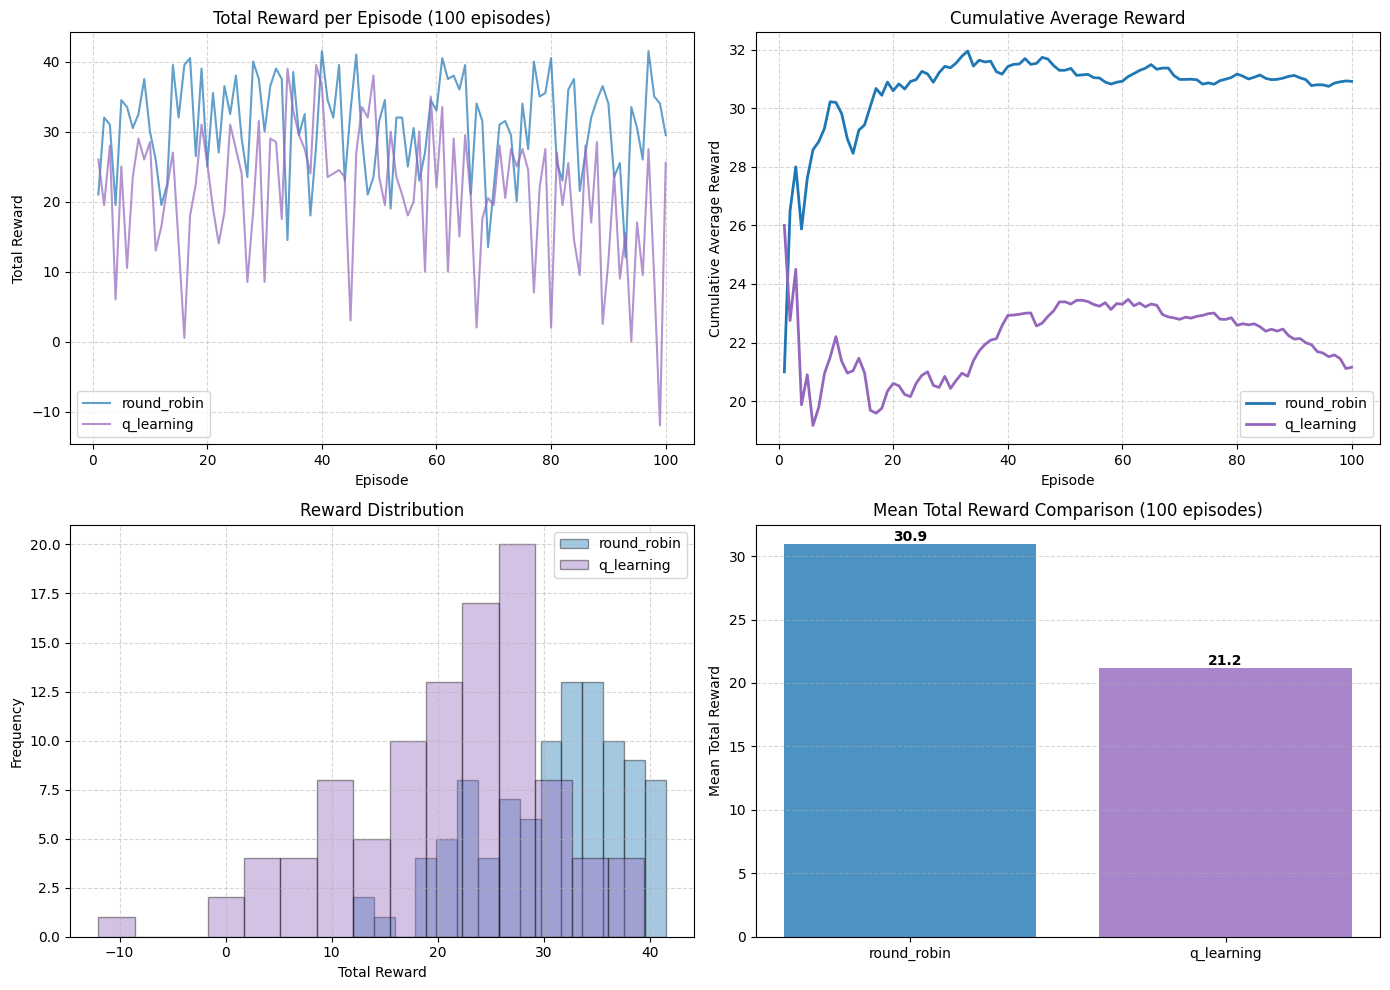

In [ ]:
import numpy as np

if __name__ == "__main__":
      N_EPISODES = 100
      N_STEPS = 20
      CSV_FILENAME = "metrics_all_policies.csv"

      all_episode_metrics = []

      # Round-robin metrics (step-level)
      print("\n" + "=" * 60)
      print("ROUND-ROBIN EVALUATION")
      print("=" * 60)
      rr_episode_rewards = []

      for ep in range(N_EPISODES):
            env = LoadBalancingEnv(n_servers=3, queue_capacity=2, seed=ep)
            obs, info = env.reset(seed=ep)
            reset_round_robin(env)

            for step in range(N_STEPS):
                  action = load_balancing_policy(option="round_robin", env=env)
                  obs, reward, terminated, truncated, info = env.step(action)

                  all_episode_metrics.append({
                        "policy": "round_robin",
                        "episode": ep + 1,
                        "step": step + 1,
                        "action": action,
                        "total_time": info["time"],
                        "total_created": info["total_created"],
                        "accepted": info["accepted"],
                        "dropped": info["dropped"],
                        "completed": info["completed"],
                        "reward": round(reward, 2),
                        "total_reward": round(info["total_reward"], 2),
                        "drop_rate": round(info["drop_rate"], 4),
                        "completion_rate": round(info["completion_rate"], 4),
                  })

                  if terminated or truncated:
                        break

            rr_episode_rewards.append(env.total_reward)

      print(f"[round_robin] Avg episode reward: {np.mean(rr_episode_rewards):.2f}")

      # Tune + train Q-learning
      print("\n" + "=" * 60)
      print("Q-LEARNING TUNING + TRAINING")
      print("=" * 60)
      best_cfg, q_agent = tune_q_learning_hyperparams(n_episodes=N_EPISODES, n_steps=N_STEPS)
      print(
            "[q_learning] Best config: "
            f"alpha={best_cfg['alpha']}, gamma={best_cfg['gamma']}, "
            f"epsilon_decay={best_cfg['epsilon_decay']}, psilon_min={best_cfg['epsilon_min']}"
      )

      # Q-learning evaluation metrics (step-level)
      print("\n" + "=" * 60)
      print("Q-LEARNING EVALUATION")
      print("=" * 60)
      q_eval_rewards, q_step_metrics = evaluate_q_learning_agent(
            q_agent,
            n_episodes=N_EPISODES,
            n_steps=N_STEPS,
            seed_offset=1000,
      )
      all_episode_metrics.extend(q_step_metrics)
      print(f"[q_learning] Avg episode reward: {np.mean(q_eval_rewards):.2f}")

      # Save all metrics from all policies in one CSV
      save_episode_metrics_csv(all_episode_metrics, filename=CSV_FILENAME)

      # Read CSV and compute final metrics for each policy
      policy_metrics = calculate_metrics_from_csv(filename=CSV_FILENAME)

      print("\n" + "=" * 60)
      print("SUMMARY FROM CSV")
      print("=" * 60)
      for policy in ["round_robin", "q_learning"]:
            if policy not in policy_metrics:
                  continue
            m = policy_metrics[policy]
            print(f"\n--- {policy} ---")
            print(f"Average reward:      {m['average_reward']:.2f}")
            print(f"Drop rate:           {m['drop_rate']:.4f}")
            print(f"Completion rate:     {m['completion_rate']:.4f}")
            print(f"Avg total time:      {m['avg_total_time']:.2f}")
            print(f"Avg total created:   {m['avg_total_created']:.2f}")
            print(f"Avg accepted:        {m['avg_accepted']:.2f}")
            print(f"Avg dropped:         {m['avg_dropped']:.2f}")
            print(f"Avg completed:       {m['avg_completed']:.2f}")

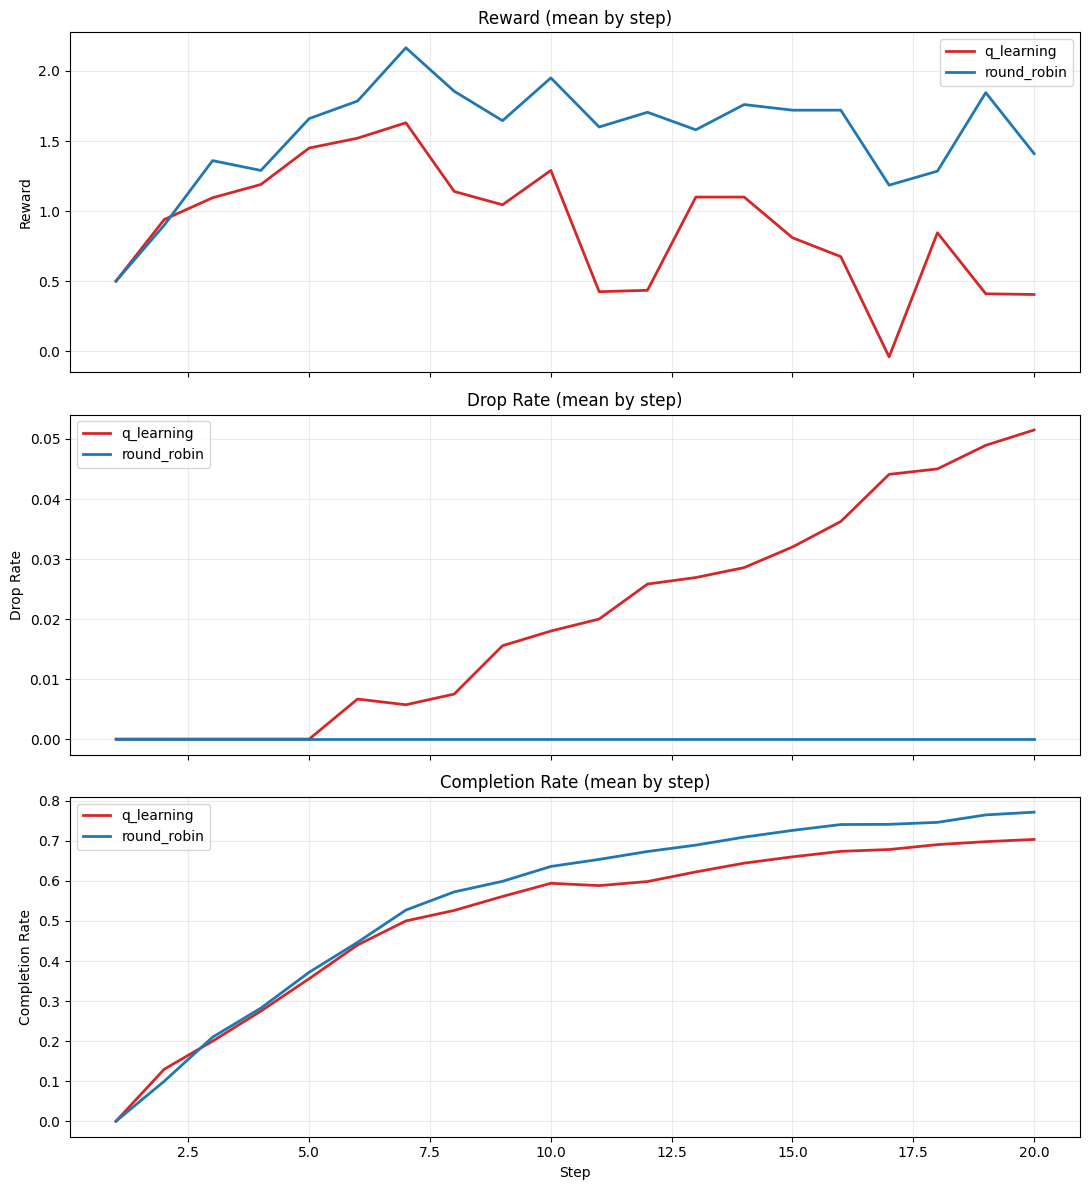

Policy summary (mean over all episodes and steps):
     policy  avg_step_reward  avg_drop_rate  avg_completion_rate
 q_learning          0.89825       0.020628             0.506972
round_robin          1.54600       0.000000             0.548069


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Load metrics generated by the benchmark cell
metrics_path = "metrics_all_policies.csv"
df = pd.read_csv(metrics_path)

required_cols = {"policy", "step", "reward", "drop_rate", "completion_rate"}
missing_cols = required_cols - set(df.columns)
if missing_cols:
    raise ValueError(f"Missing required columns in {metrics_path}: {sorted(missing_cols)}")

# Average step-level trajectory across episodes for each policy
step_traj = (
    df.groupby(["policy", "step"], as_index=False)[["reward", "drop_rate", "completion_rate"]]
    .mean()
)

policies = sorted(step_traj["policy"].unique())
colors = {
    "round_robin": "#1f77b4",
    "q_learning": "#d62728",
}

fig, axes = plt.subplots(3, 1, figsize=(11, 12), sharex=True)
metric_specs = [
    ("reward", "Reward (mean by step)", "Reward"),
    ("drop_rate", "Drop Rate (mean by step)", "Drop Rate"),
    ("completion_rate", "Completion Rate (mean by step)", "Completion Rate"),
]

for ax, (metric_col, title, y_label) in zip(axes, metric_specs):
    for policy in policies:
        sub = step_traj[step_traj["policy"] == policy]
        ax.plot(
            sub["step"],
            sub[metric_col],
            label=policy,
            linewidth=2.0,
            color=colors.get(policy, None),
        )
    ax.set_title(title)
    ax.set_ylabel(y_label)
    ax.grid(alpha=0.25)
    ax.legend()

axes[-1].set_xlabel("Step")
plt.tight_layout()
plt.show()

# Compact policy-level summary for interpretation
summary = (
    df.groupby("policy", as_index=False)[["reward", "drop_rate", "completion_rate"]]
    .mean()
    .rename(
        columns={
            "reward": "avg_step_reward",
            "drop_rate": "avg_drop_rate",
            "completion_rate": "avg_completion_rate",
        }
    )
)

print("Policy summary (mean over all episodes and steps):")
print(summary.to_string(index=False))

Evaluation and Analysis

## CONGRATULATIONS TEAM!

Congratulations to the team for completing Lab02 - Introduction to Q-learning.
Keep up the effort in the next sections.

References: https://gymnasium.farama.org/ 

## ADDITIONAL INFORMATION

**Author**: M.Sc. Phan Trung Phat - Department of Computer Networks and Communications, UIT

**Contact**: phatpt@uit.edu.vn
